In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [4]:
def compute_lower_convex_hull(df, x_key, y_key, reduced=True):
    """Compute lower convex hull (minimize both x and y)."""
    all_points = []
    point_to_run_idx = {}
    for run_idx, run in df.iterrows():
        mask = ~np.isnan(run['history'][y_key])
        x_vals = run['history'][x_key][mask].values
        y_vals = run['history'][y_key][mask].values
        for i, (x, y) in enumerate(zip(x_vals, y_vals)):
            all_points.append((x, y))
            point_to_run_idx[(x, y)] = (run_idx, i)
    if len(all_points) < 2:
        return sorted(all_points, key=lambda p: p[0]), point_to_run_idx
    sorted_points = sorted(all_points, key=lambda p: p[0])
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
    hull = []
    for point in sorted_points:
        while len(hull) >= 2 and cross(hull[-2], hull[-1], point) <= 0:
            hull.pop()
        if len(hull) > 0:
            min_y_so_far = min(p[1] for p in hull)
            if point[1] - min_y_so_far > 0.01 * max(min_y_so_far, point[1]):
                continue
        hull.append(point)
    if reduced:
        run_to_points = {}
        for point in hull:
            run_idx, _ = point_to_run_idx[point]
            run_to_points.setdefault(run_idx, []).append(point)
        hull = []
        for points in run_to_points.values():
            x_vals = [p[0] for p in points]
            median_idx = np.argmin([abs(x - np.median(x_vals)) for x in x_vals])
            hull.append(points[median_idx])
    return sorted(hull, key=lambda p: p[0]), point_to_run_idx

In [5]:
filters = {
    'config.tag': 'eca_emergence',
    'config.T': 6781,
    'config.requential': True,
    'config.student_speed': 1,
    "state": {"$in": ["finished", "running"]}
}
runs = get_runs("shikai/requential", filters)
runs['P_raw'] = runs['P']
runs = runs[runs['P'].notna()]
runs['P'] = (runs['P'] / 1e6).apply(lambda x: round(x, -int(np.floor(np.log10(abs(x)))) if x != 0 else 0))
print(f'{len(runs)} runs loaded')

89 runs loaded


In [6]:
runs = runs[runs['history'].apply(lambda h: len(h) > 0)]
all_runs = runs

eca_steps = 64
width = 64
runs['loops'] = (eca_steps / runs['meta/predict_freq']).astype(int)
runs = all_runs[all_runs['loops'].isin([1, 4, 16])]
runs['len'] = width * (eca_steps / runs['meta/predict_freq'])
mask = runs['len'] == runs['meta/target_len']
runs = runs[mask]

/tmp/ipykernel_1614233/2839568469.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  runs['len'] = width * (eca_steps / runs['meta/predict_freq'])


In [7]:
runs.loc[:, 'history'] = runs['history'].apply(
    lambda hist: pd.DataFrame({k: v for k, v in hist.items()})
)

def set_test_tokens(df, test_tokens, req=True):
    for idx, row in df.iterrows():
        if req:
            df.at[idx, 'history']['K(M)'] = row['history']['K_req'] / np.log(2)
            df.at[idx, 'history']['K(X|M)'] = row['history']['ema_student_loss'] * test_tokens * row['loops'] / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens * (1 + row['loops']) / 2
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']
        else:
            df.at[idx, 'history']['K(M)'] = row['history']['K_auc'] / np.log(2)
            df.at[idx, 'history']['K(X|M)'] = row['history']['train_loss'] * test_tokens * row['loops'] / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens * (1 + row['loops']) / 2
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']

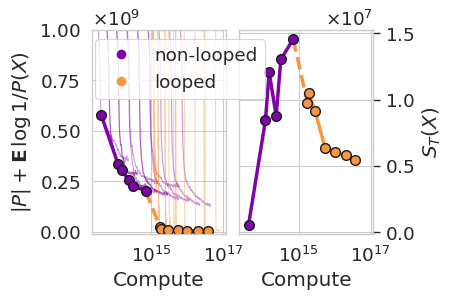

In [8]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

selected_loops = [1, 16]
loop_labels = {1: 'non-looped', 16: 'looped'}

x_key = 'total_compute'
test_tokens = 1e9
req = True
D_min = 32
y_max = test_tokens

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.3, 3), sharex=True)

cmap = sns.color_palette('plasma', len(runs['loops'].unique()))
loop_colors = {1: cmap[0], 16: cmap[-1]}

set_test_tokens(runs, test_tokens, req)

# Find global max x value
global_max_x = 0
for loop in selected_loops:
    df_loop = runs[runs['loops'] == loop]
    if loop == 1:
        df_loop = df_loop[df_loop['D'] >= D_min]
    for _, run in df_loop.iterrows():
        mask = ~np.isnan(run['history']['K(M,X)'])
        if mask.any():
            max_x = run['history'][x_key][mask].max()
            global_max_x = max(global_max_x, max_x)

def compute_non_convex_pareto(points):
    if len(points) == 0:
        return []
    sorted_points = sorted(points, key=lambda p: (p[0], p[1]))
    pareto = []
    min_y = float('inf')
    for point in sorted_points:
        if point[1] < min_y:
            pareto.append(point)
            min_y = point[1]
    return pareto

# Collect Pareto points from each loop
all_pareto_points = []
for loop in selected_loops:
    df_loop = runs[runs['loops'] == loop]
    if loop == 1:
        df_loop = df_loop[df_loop['D'] >= D_min]
    loop_pareto_points, loop_point_to_run_idx = compute_lower_convex_hull(
        df_loop, x_key, 'K(M,X)', reduced=True
    )
    for pareto_point in loop_pareto_points:
        run_idx, hist_idx = loop_point_to_run_idx[pareto_point]
        run = runs.loc[run_idx]
        mask = ~np.isnan(run['history']['K(M,X)'])
        masked_indices = np.where(mask)[0]
        if hist_idx < len(masked_indices):
            actual_idx = masked_indices[hist_idx]
            x_val = run['history'][x_key].iloc[actual_idx]
            y_val = run['history']['K(M,X)'].iloc[actual_idx]
            all_pareto_points.append((x_val, y_val, loop, run_idx, actual_idx))

global_pareto_points = compute_non_convex_pareto(all_pareto_points)

# Plot all runs with transparency (first panel only)
for loop in selected_loops:
    df_loop = runs[runs['loops'] == loop]
    if loop == 1:
        df_loop = df_loop[df_loop['D'] >= D_min]
    loop_color = loop_colors[loop]
    for _, run in df_loop.iterrows():
        mask = ~np.isnan(run['history']['K(M,X)'])
        x_data = run['history'][x_key][mask]
        y_data = run['history']['K(M,X)'][mask]
        if len(x_data) > 100:
            indices = np.linspace(0, len(x_data) - 1, 100, dtype=int)
            x_data = x_data.iloc[indices]
            y_data = y_data.iloc[indices]
        ax1.plot(x_data, y_data, c=loop_color, alpha=0.4, linewidth=0.8)

# Plot global Pareto frontier
for ax, y_key in zip([ax1, ax2], ['K(M,X)', 'K(M)']):
    pareto_data = []
    for point in global_pareto_points:
        x_val, _, loop, run_idx, actual_idx = point
        run = runs.loc[run_idx]
        y_val = run['history'][y_key].iloc[actual_idx]
        pareto_data.append((x_val, y_val, loop))
    if pareto_data:
        pareto_data.sort(key=lambda p: p[0])
        pareto_x = [p[0] for p in pareto_data]
        pareto_y = [p[1] for p in pareto_data]
        pareto_loops = [p[2] for p in pareto_data]
        if len(pareto_x) > 100:
            indices = np.linspace(0, len(pareto_x) - 1, 100, dtype=int)
            pareto_x = [pareto_x[i] for i in indices]
            pareto_y = [pareto_y[i] for i in indices]
            pareto_loops = [pareto_loops[i] for i in indices]
        for i in range(len(pareto_x) - 1):
            x_segment = [pareto_x[i], pareto_x[i+1]]
            y_segment = [pareto_y[i], pareto_y[i+1]]
            loop1, loop2 = pareto_loops[i], pareto_loops[i+1]
            if loop1 == loop2:
                segment_color = loop_colors[loop1]
                linestyle = '-'
            else:
                segment_color = loop_colors[loop2]
                linestyle = '--'
            ax.plot(x_segment, y_segment, c=segment_color, linewidth=2.5, alpha=1, linestyle=linestyle)
        for x, y, loop in zip(pareto_x, pareto_y, pareto_loops):
            ax.plot(x, y, marker='o', markersize=7, c=loop_colors[loop], alpha=1, mec='k', mew=1)
    ax.set_ylabel(r'$|P| + \mathbf{E}\,\log 1/P(X)$' if y_key == 'K(M,X)' else r'$S_T(X)$')
    ymax = ax.get_ylim()[1]
    if ymax > y_max:
        ax.set_ylim(-10, y_max)
    ax.set_xscale('log')

ax1.set_xlabel('Compute')
ax2.set_xlabel('Compute')
ax1.set_ylim(-1e7, 1e9)
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()

legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=loop_colors[loop],
                             markersize=8, label=loop_labels[loop])
                 for loop in selected_loops]
fig.legend(handles=legend_handles, loc='center', bbox_to_anchor=(0.33, 0.75), frameon=True, ncol=1)

for ax in [ax1, ax2]:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(formatter)

plt.subplots_adjust(wspace=0.1, right=0.78, bottom=0.2)
plt.show()